In [18]:
import sys
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\saksh\OneDrive - University of Keele\Desktop\Ecommerce_project")
sys.path.append(str(PROJECT_ROOT))

import shap
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

from src.data.loader import load_data
from src.features.engineering import add_engineered_features
from src.config.settings import load_config

config = load_config()
MODELS_DIR = PROJECT_ROOT / "src" / "models"

In [19]:
# Match save_model.py: do NOT use get_dummies — the fitted pipeline handles encoding + scaling
df = load_data()
df = add_engineered_features(df)

X = df.drop(config["target_column"], axis=1)
y = df[config["target_column"]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config["test_size"], random_state=config["random_seed"]
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

2026-08-29 10:38:56,273 | INFO | src.data.loader | Data loaded successfully from C:/Users/saksh/OneDrive - University of Keele/Desktop/Ecommerce_project/dataset/ecommerce_sessions.csv.
2026-08-29 10:38:56,298 | INFO | src.data.loader | All expected columns are present in the dataset.
2026-08-29 10:38:56,337 | INFO | src.features.engineering | Engineered features added to the DataFrame.


Train: (9600, 21), Test: (2400, 21)


In [20]:
final_model = joblib.load(MODELS_DIR / "final_model.pkl")
preprocessor = joblib.load(MODELS_DIR / "preprocessing_pipeline.pkl")

X_test_processed = preprocessor.transform(X_test)
if hasattr(X_test_processed, "toarray"):
    X_test_dense = X_test_processed.toarray()
else:
    X_test_dense = np.asarray(X_test_processed)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_dense)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f"SHAP values shape: {shap_values.shape}")
print("Explainer ready.")

SHAP values shape: (2400, 79)
Explainer ready.


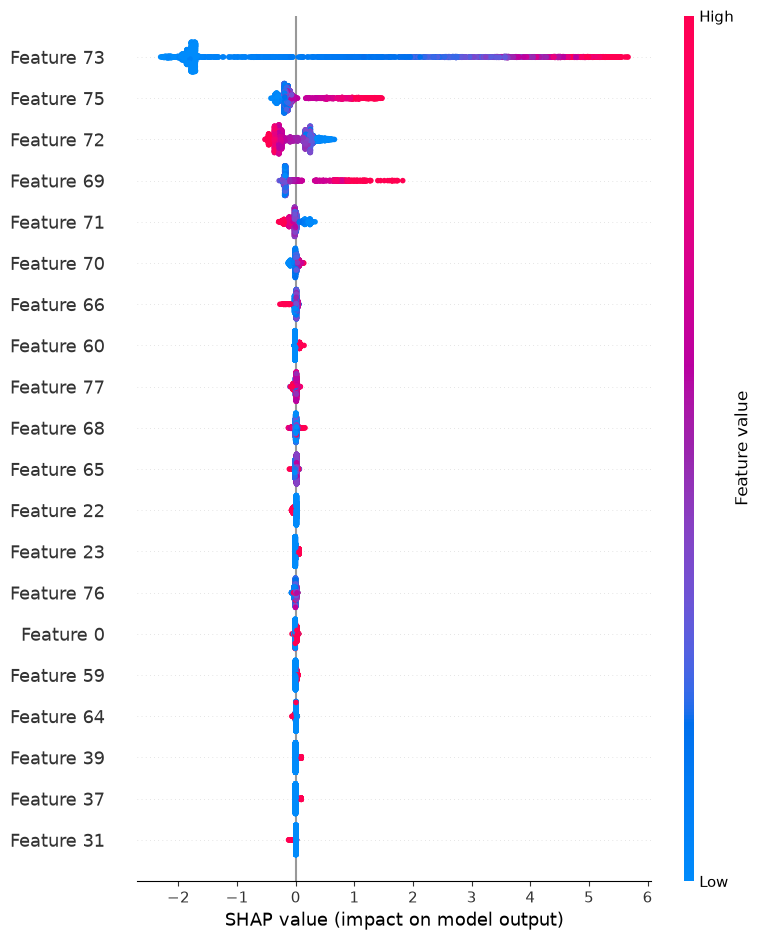

In [21]:
import matplotlib.pyplot as plt
shap.summary_plot(shap_values, X_test_dense)

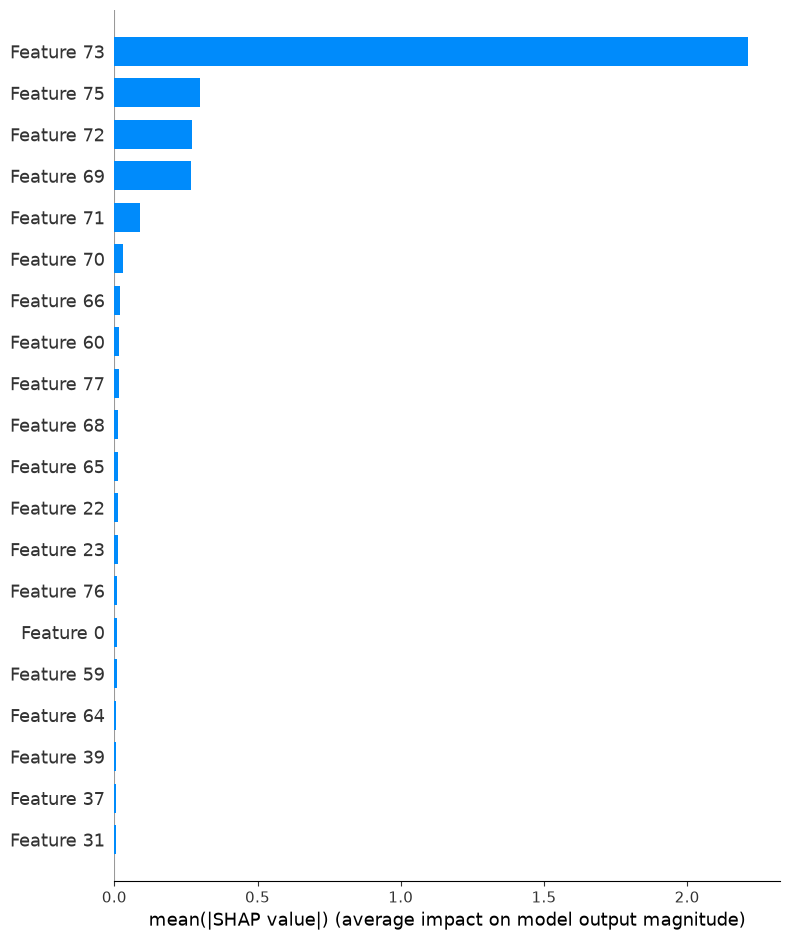

In [22]:
shap.summary_plot(shap_values, X_test_dense, plot_type="bar")


In [23]:
# Save summary plot
shap.summary_plot(shap_values, X_test_dense, show=False)
plt.savefig(r"C:\Users\saksh\OneDrive - University of Keele\Desktop\Ecommerce_project\reports\shap_summary_plot.png", bbox_inches="tight")
plt.close()

# Save bar plot
shap.summary_plot(shap_values, X_test_dense, plot_type="bar", show=False)
plt.savefig(r"C:\Users\saksh\OneDrive - University of Keele\Desktop\Ecommerce_project\reports\shap_bar_plot.png", bbox_inches="tight")
plt.close()

print("Plots saved to reports/")

Plots saved to reports/


In [24]:
probs = final_model.predict_proba(X_test_dense)[:, 1]

clear_buyer_index = probs.argmax()
clear_non_buyer_index = probs.argmin()
uncertain_index = (abs(probs - 0.4)).argmin()

print(f"Clear buyer: {clear_buyer_index}, Clear non-buyer: {clear_non_buyer_index}, Uncertain: {uncertain_index}")
print(f"Clear buyer probability: {probs[clear_buyer_index]:.4f}, Clear non-buyer probability: {probs[clear_non_buyer_index]:.4f}, Uncertain probability: {probs[uncertain_index]:.4f}")





Clear buyer: 199, Clear non-buyer: 1652, Uncertain: 2336
Clear buyer probability: 0.9891, Clear non-buyer probability: 0.0006, Uncertain probability: 0.3989


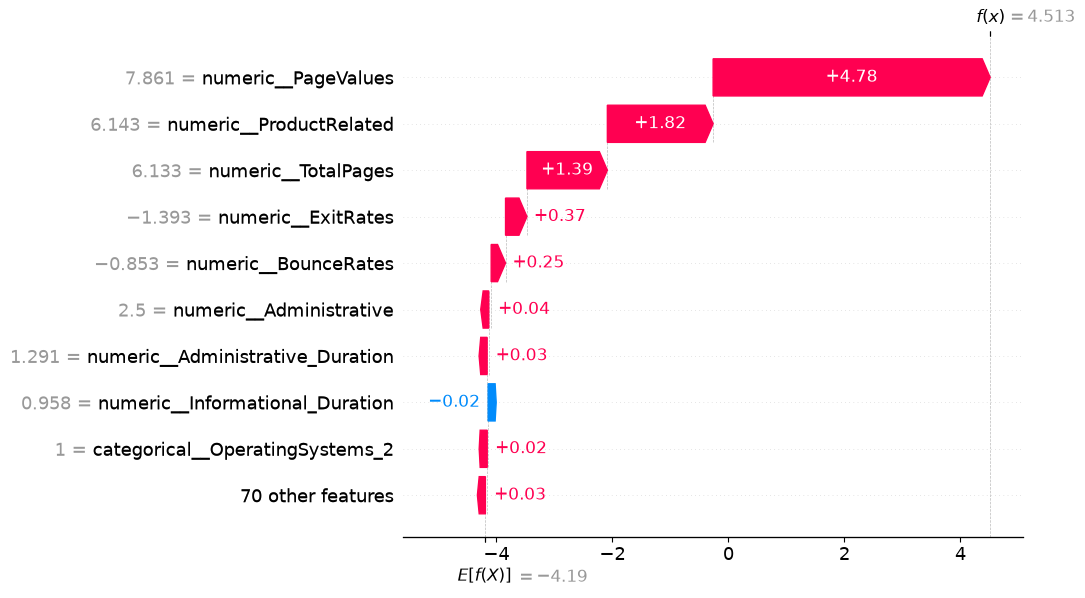

In [27]:
# Use pipeline feature names (79), not raw X_test columns (21)
feature_names = list(preprocessor.get_feature_names_out())
base_value = explainer.expected_value
if not np.isscalar(base_value):
    base_value = base_value[1]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[clear_buyer_index],
        base_values=base_value,
        data=X_test_dense[clear_buyer_index],
        feature_names=feature_names,
    )
)




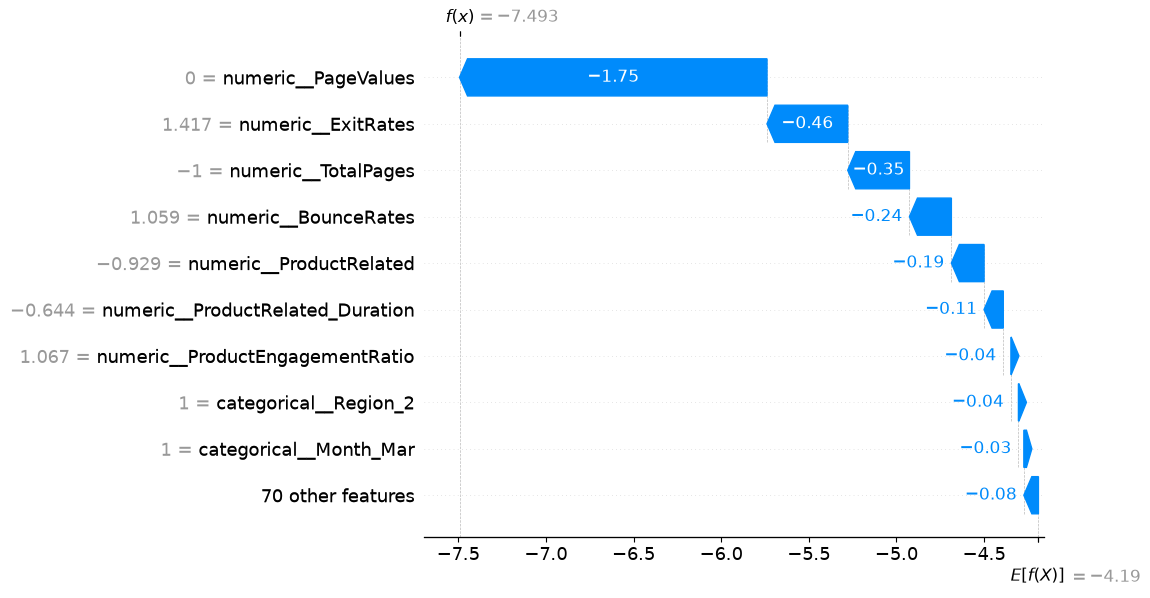

In [28]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[clear_non_buyer_index],
        base_values=base_value,
        data=X_test_dense[clear_non_buyer_index],
        feature_names=feature_names,
    )
)

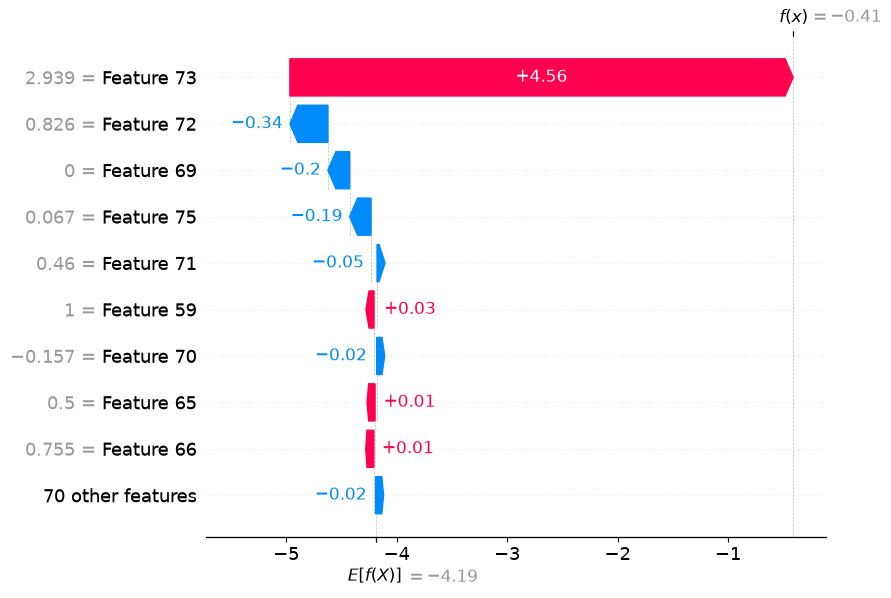

In [29]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[uncertain_index],
        base_values=base_value,
        data=X_test_dense[uncertain_index]
    )
)

In [32]:
from lime.lime_tabular import LimeTabularExplainer

# LIME needs numeric processed data (same as the model), not raw strings
X_train_processed = preprocessor.transform(X_train)
X_train_dense = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else np.asarray(X_train_processed)

line_explainer = LimeTabularExplainer(
    X_train_dense,
    feature_names=list(preprocessor.get_feature_names_out()),
    class_names=["No Purchase", "Purchase"],
    mode="classification",
)

In [35]:
from IPython.display import HTML

lime_exp_buyer = line_explainer.explain_instance(
    X_test_dense[clear_buyer_index],
    final_model.predict_proba,
    num_features=10,
)

# White background so the LIME HTML plot is readable
HTML(f'<div style="background-color:white; padding:10px;">{lime_exp_buyer.as_html()}</div>')

In [36]:
from IPython.display import HTML

lime_exp_non_buyer = line_explainer.explain_instance(
    X_test_dense[clear_non_buyer_index],
    final_model.predict_proba,
    num_features=10,
)

# White background so the LIME HTML plot is readable
HTML(f'<div style="background-color:white; padding:10px;">{lime_exp_non_buyer.as_html()}</div>')

In [37]:
from IPython.display import HTML

lime_exp_uncertain = line_explainer.explain_instance(
    X_test_dense[uncertain_index],
    final_model.predict_proba,
    num_features=10,
)

# White background so the LIME HTML plot is readable
HTML(f'<div style="background-color:white; padding:10px;">{lime_exp_uncertain.as_html()}</div>')

### SHAP vs LIME comparison (same 3 sessions)

**Clear buyer (row 199):** Both methods agree that **PageValues** is the main reason for the high purchase prediction. SHAP and LIME also both highlight **TotalPages** and **ProductRelated** as supporting positive drivers, so the two explanations match closely.

**Clear non-buyer (row 1652):** Again both point to **PageValues = 0 / low** as the strongest negative driver, with **ExitRates** and **TotalPages** also pushing against purchase. Ranking details differ a little (LIME also surfaces some categorical flags), but the core story is the same.

**Uncertain (row 2336):** Both methods say **PageValues** pushes toward purchase while **ExitRates** (and weaker product/page activity) pull the other way — which is why the model ends up near the decision boundary.

**Overall:** SHAP and LIME largely agree on the top features for these sessions, especially **PageValues**. That agreement makes the explanations more trustworthy, since two different methods tell a similar story.
